In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

In [4]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
seed = 1


In [5]:
from mbt_gym.stochastic_processes.midprice_models import ArithmeticBrownianMotionWithFadsMidpriceModel

### Parameters

In [6]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.2 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
gamma = 1
alpha=0.001
mu=0
big_phi = 0.1

In [7]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)
# intensity =  np.array([psi + phi, psi + phi])  # intensity for PoissonArrivalModel

psi value: 14.985756598048642


In [8]:
def get_as_env(num_trajectories:int = 1):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [9]:
as_env = get_as_env()

In [10]:
as_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


In [11]:
observations, actions, rewards = generate_trajectory(as_env, as_agent)

In [12]:
print(observations.shape)

(1, 7, 1001)


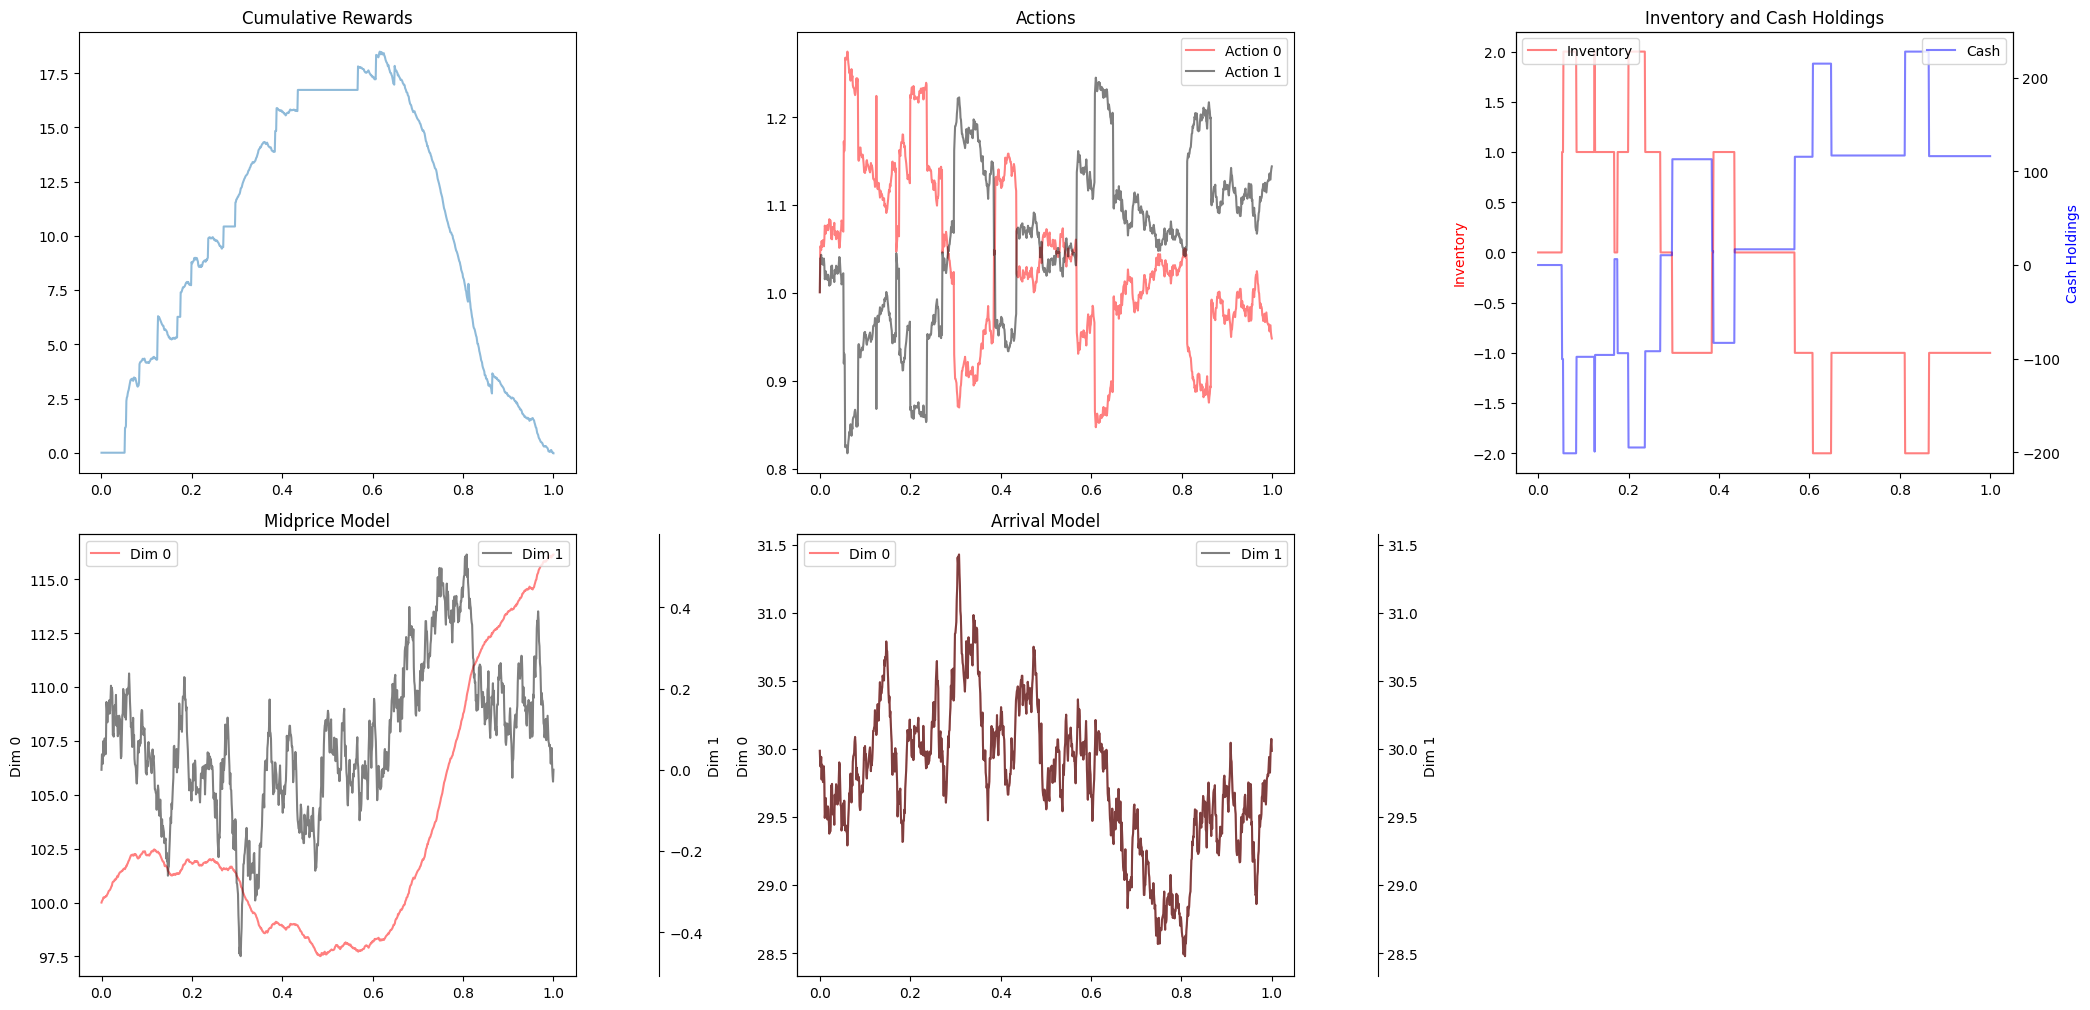

In [13]:
plot_trajectory_extended(as_env, as_agent)

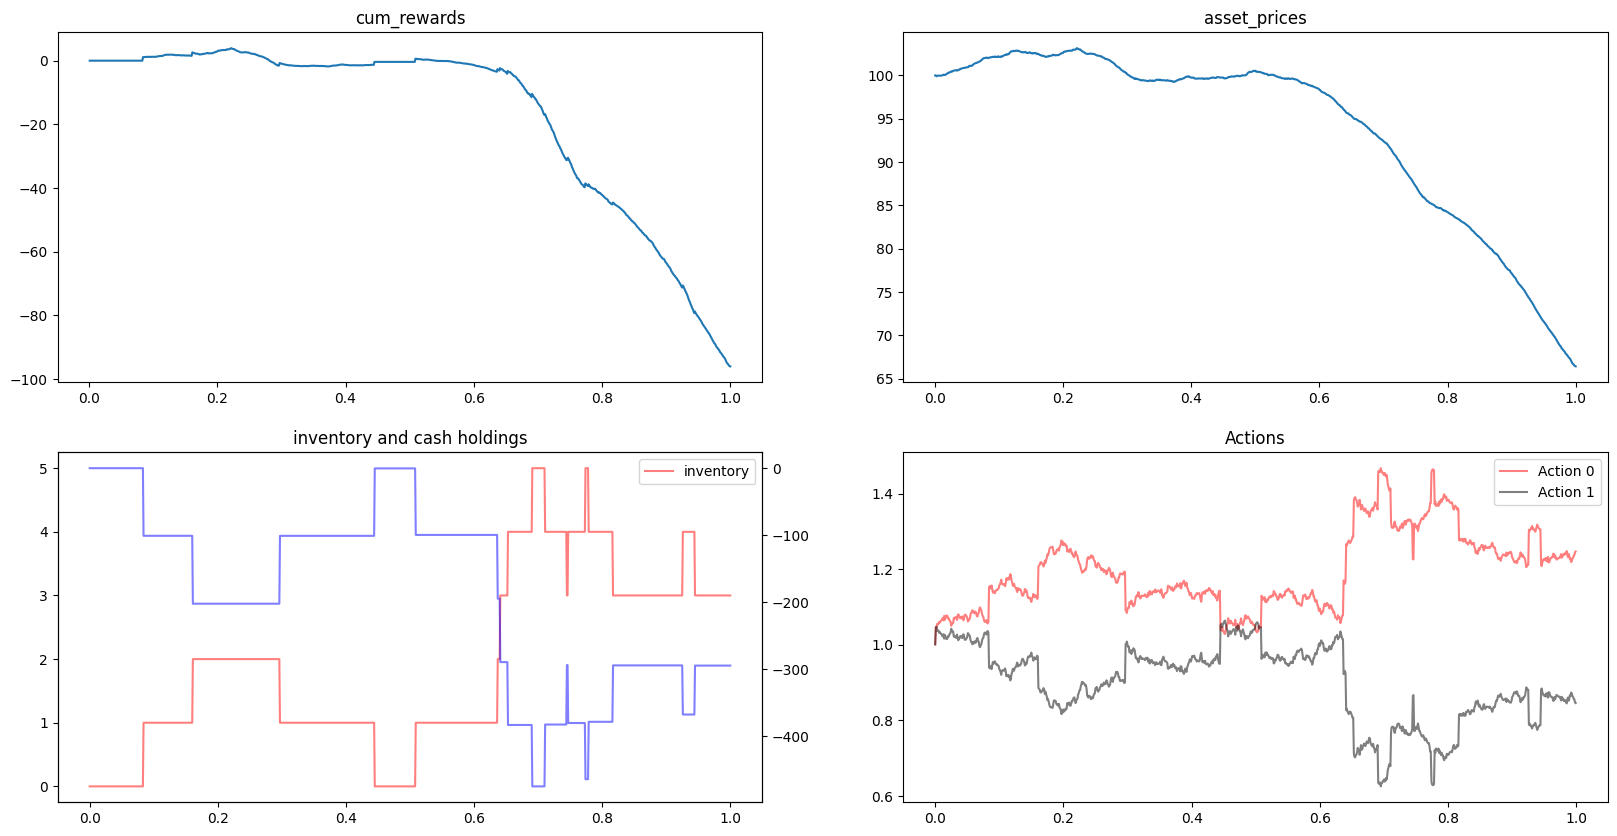

In [14]:
plot_trajectory(as_env, as_agent, seed = seed)

In [15]:
num_trajectories = 1000
vec_env = get_as_env(num_trajectories)
vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)

print(vec_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [16]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [17]:
initial_fads = 0
TrueMean= initial_fads * np.exp(-eta * terminal_time)
fad_trajectories = observations[:, FADS_INDEX, :]  # shape: (num_trajectories, n_steps+1)

simulated_mean = np.mean(fad_trajectories, axis=0)

print("Simulated mean of the fad at terminal time:", simulated_mean)
print("True mean of the fad at terminal time:", TrueMean)

Simulated mean of the fad at terminal time: [ 0.         -0.00199396 -0.00122523 ... -0.00063407 -0.00186566
 -0.00168254]
True mean of the fad at terminal time: 0.0


In [18]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [19]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.092425,18.202207,37.427907,0.063,2.305001


In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_actions_vs_fad_colored(observations, actions, max_traj=None):
    """
    Plot ask (solid markers) and bid (dashed markers) spreads vs fad (Ut),
    with inventory as color shading, looping over multiple trajectories.
    
    Parameters
    ----------
    observations : np.ndarray
        Shape (n_traj, 7, T+1)
    actions : np.ndarray
        Shape (n_traj, 2, T)
    max_traj : int or None
        Maximum number of trajectories to include (default: all)
    """
    n_traj = observations.shape[0]
    print(f"Total trajectories available: {n_traj}")
    if max_traj is None:
        max_traj = n_traj

    all_fad = []
    all_inv = []
    all_ask = []
    all_bid = []

    # Collect data from multiple trajectories
    for traj_idx in range(min(max_traj, n_traj)):
        print(f"Processing trajectory {traj_idx+1}/{min(max_traj, n_traj)}")
        obs = observations[traj_idx, :, :-1]  # (7, T)
        acts = actions[traj_idx]              # (2, T)

        fad = obs[4]          # fad Ut
        inventory = obs[1]    # inventory Q
        bid_spread = acts[0]
        ask_spread = acts[1]

        all_fad.append(fad)
        all_inv.append(inventory)
        all_ask.append(ask_spread)
        all_bid.append(bid_spread)

    # Flatten all trajectories into 1D arrays
    fad = np.concatenate(all_fad)
    inventory = np.concatenate(all_inv)
    ask_spread = np.concatenate(all_ask)
    bid_spread = np.concatenate(all_bid)

    # Plot
    plt.figure(figsize=(10, 6))

    sc1 = plt.scatter(fad, ask_spread, c=inventory, cmap="viridis",
                      alpha=0.6, label="Ask spread", marker="o", s=10)
    sc2 = plt.scatter(fad, bid_spread, c=inventory, cmap="viridis",
                      alpha=0.6, label="Bid spread", marker="x", s=10)

    plt.xlabel("Fad $U_t$")
    plt.ylabel("Spread")
    plt.title("Bid/Ask Spreads vs Fad with Inventory Coloring (all trajectories)")
    plt.legend()
    cbar = plt.colorbar(sc1)
    cbar.set_label("Inventory $Q$")
    plt.grid(True)
    plt.show()


Total trajectories available: 1000
Processing trajectory 1/10
Processing trajectory 2/10
Processing trajectory 3/10
Processing trajectory 4/10
Processing trajectory 5/10
Processing trajectory 6/10
Processing trajectory 7/10
Processing trajectory 8/10
Processing trajectory 9/10
Processing trajectory 10/10


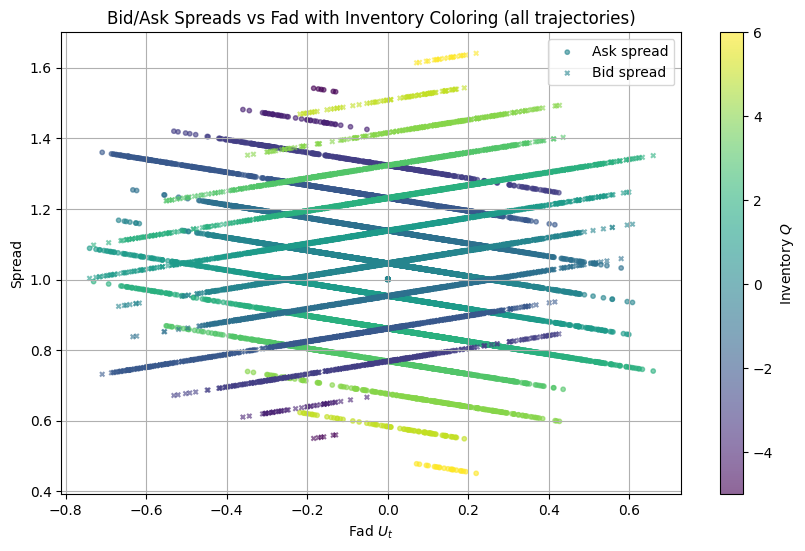

In [21]:
plot_actions_vs_fad_colored(observations, actions,10)

### Parameters

In [22]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion_values = [0.3, 0.6, 0.9]
# p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10.0
phi = 15
k = 1
gamma = 1
alpha=0.001
mu=0
big_phi=0.1

In [23]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi_values = {q: compute_psi(q) for q in fads_proportion_values}

print("psi values:", psi_values)

psi values: {0.3: 14.967970890292623, 0.6: 14.872283180889763, 0.9: 14.71412778506946}


In [24]:

def get_as_env(num_trajectories:int = 1, fads_proportion:float=0.6, psi:float=15):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [25]:
results_dict = {}
actions_dict = {}
for fads_proportion in fads_proportion_values:
    vec_env = get_as_env(num_trajectories=1000, fads_proportion=fads_proportion, psi=psi_values[fads_proportion])

    vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(
      env=vec_env
    )

    observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)

    results_dict[fads_proportion] = dict(results=results, rewards=total_rewards, obs=observations)

    actions_dict[fads_proportion] = actions

✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/../mbt_gym/agents/BaselineAgents.py:526: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


✓ Pre-computed ODE solutions for 1000 time points


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/../mbt_gym/agents/BaselineAgents.py:526: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


In [26]:
def plot_actions_vs_fad_subplots(results_dict, actions_dict, fads_proportions, max_traj=None):
    """
    Create subplots for ask/bid spreads vs fad, colored by inventory,
    one subplot per fads_proportion.

    Parameters
    ----------
    results_dict : dict
        Dictionary with entries like results_dict[fads_proportion]["obs"] = observations
    actions_dict : dict
        Dictionary with entries like actions_dict[fads_proportion] = actions
    fads_proportions : list
        List of fads_proportion values to plot
    max_traj : int or None
        Maximum number of trajectories to include per subplot (default: all)
    """
    n_cols = len(fads_proportions)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=True)

    if n_cols == 1:
        axes = [axes]  # ensure iterable if only one proportion

    for ax, fads_prop in zip(axes, fads_proportions):
        obs = results_dict[fads_prop]["obs"]
        acts = actions_dict[fads_prop]

        n_traj = obs.shape[0]
        if max_traj is None:
            max_traj = n_traj

        all_fad, all_inv, all_ask, all_bid = [], [], [], []

        for traj_idx in range(min(max_traj, n_traj)):
            o = obs[traj_idx, :, :-1]  # (7, T)
            a = acts[traj_idx]         # (2, T)

            fad = o[4]
            inventory = o[1]
            bid_spread = a[0]
            ask_spread = a[1]


            all_fad.append(fad)
            all_inv.append(inventory)
            all_ask.append(ask_spread)
            all_bid.append(bid_spread)

        # Flatten
        fad = np.concatenate(all_fad)
        inventory = np.concatenate(all_inv)
        ask_spread = np.concatenate(all_ask)
        bid_spread = np.concatenate(all_bid)

        # Plot
        sc1 = ax.scatter(fad, ask_spread, c=inventory, cmap="viridis",
                         alpha=0.5, marker="o", s=10, label="Ask spread")
        sc2 = ax.scatter(fad, bid_spread, c=inventory, cmap="viridis",
                         alpha=0.5, marker="x", s=10, label="Bid spread")

        ax.set_title(f"fads_proportion = {fads_prop}")
        ax.set_xlabel("Fad $U_t$")
        ax.set_ylabel("Spread")
        ax.legend()
        ax.grid(True)

    # Add shared colorbar
    cbar = fig.colorbar(sc1, ax=axes, orientation="horizontal", fraction=0.05, pad=0.2, aspect=40)
    cbar.set_label("Inventory $Q$")
    plt.suptitle("Bid/Ask Spreads vs Fad for different fad proportions", fontsize=14)
    



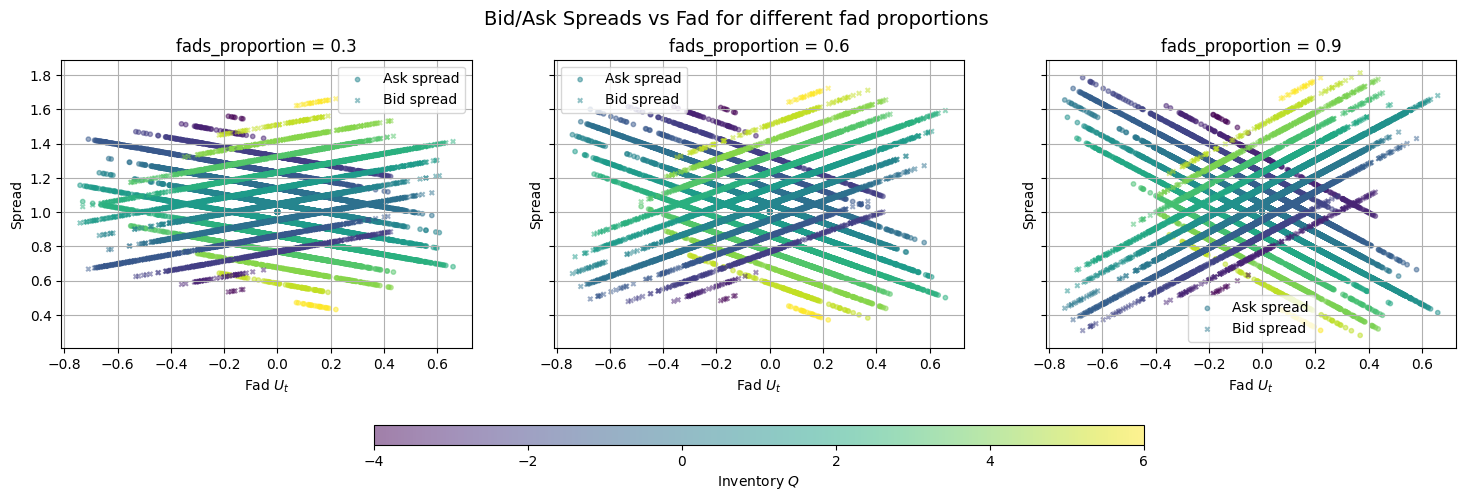

In [27]:
plot_actions_vs_fad_subplots(results_dict, actions_dict, fads_proportions=fads_proportion_values, max_traj=10)

In [28]:
old version below

SyntaxError: invalid syntax (1371314217.py, line 1)

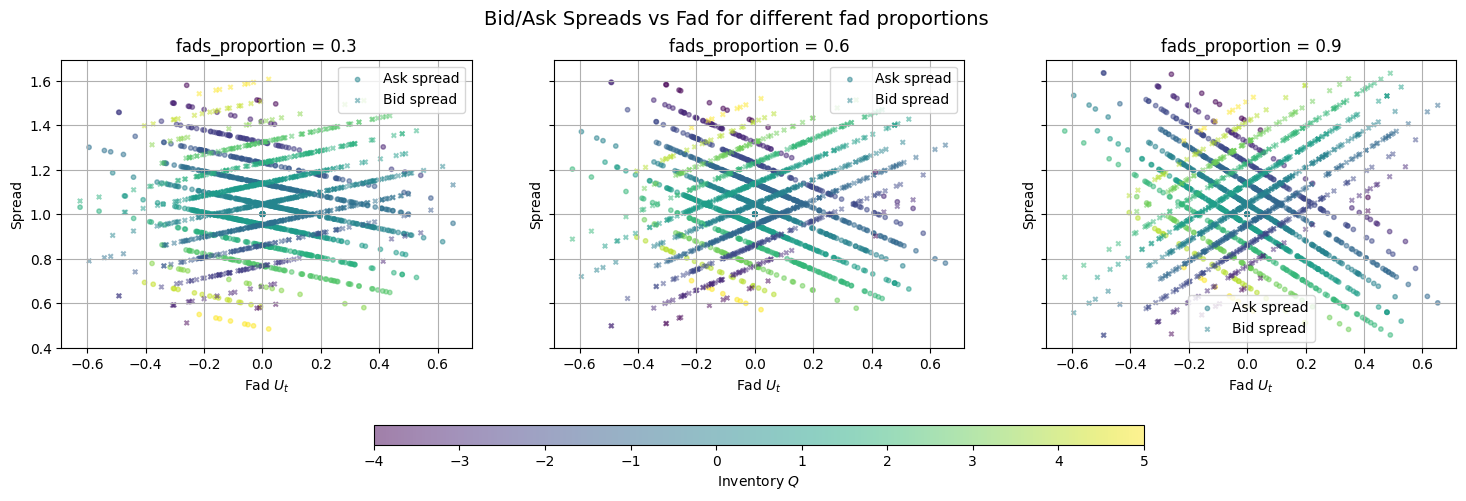

In [ ]:
plot_actions_vs_fad_subplots(results_dict, actions_dict, fads_proportions=fads_proportions, max_traj=10)


## Varying gamma parameter

### Parameters

In [41]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
gamma_values = [0.1, 10]
alpha=0.001
mu=0
big_phi = 0.1
seed = 42

In [42]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t, eta):
    return u0 * np.exp(-eta * t)

def v(t, eta):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q, eta, gamma):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t, eta) + 0.5 * (c**2) * v(t, eta))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each gamma
psi_values = {gamma: compute_psi(fads_proportion, eta, gamma) for gamma in gamma_values}

# pretty print
for gamma, val in psi_values.items():
    print(f"gamma={gamma} -> psi={val:.6f}")

gamma=0.1 -> psi=14.998718
gamma=10 -> psi=6.330244


In [43]:
def get_as_env(num_trajectories:int = 1, gamma:float=1, psi:float=15):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [44]:
results_dict = {}
for gamma in gamma_values:
    vec_env = get_as_env(num_trajectories=1, gamma=gamma, psi=psi_values[gamma])

    vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(
        env=vec_env
    )

    observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    #results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)

    results_dict[gamma] = dict(results=results, rewards=total_rewards, obs=observations)
    actions_dict[gamma] = actions


✓ Pre-computed ODE solutions for 1000 time points
✓ Pre-computed ODE solutions for 1000 time points


In [45]:
import matplotlib.pyplot as plt

def plot_inventory_fad_from_results(results_dict, gammas, traj_id=0):
    """
    Plot inventory (red, right axis) vs fad (blue, left axis) 
    for different gamma values using observations from results_dict.
    """
    fig, axes = plt.subplots(1, len(gammas), figsize=(6 * len(gammas), 4), sharex=True)

    if len(gammas) == 1:
        axes = [axes]

    for j, gamma in enumerate(gammas):
        observations = results_dict[gamma]["obs"]
        inventory = observations[traj_id, 1, :]   # Q_t
        fad       = observations[traj_id, 4, :]   # U_t
        t_grid    = range(observations.shape[2])

        ax = axes[j]
        ax2 = ax.twinx()  # secondary y-axis

        # Fad on left axis
        ax.plot(t_grid, fad, 'b-', label=r'$U_t$ (Fad)')
        ax.set_ylabel("Fad", color='b')
        ax.tick_params(axis='y', labelcolor='b')

        # Inventory on right axis
        ax2.plot(t_grid, inventory, 'r-', label=r'$Q_t$ (Inventory)')
        ax2.set_ylabel("Inventory", color='r')
        ax2.tick_params(axis='y', labelcolor='r')

        # Titles and layout
        ax.set_title(fr'$\gamma = {gamma}$')
        ax.set_xlabel("Time")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()




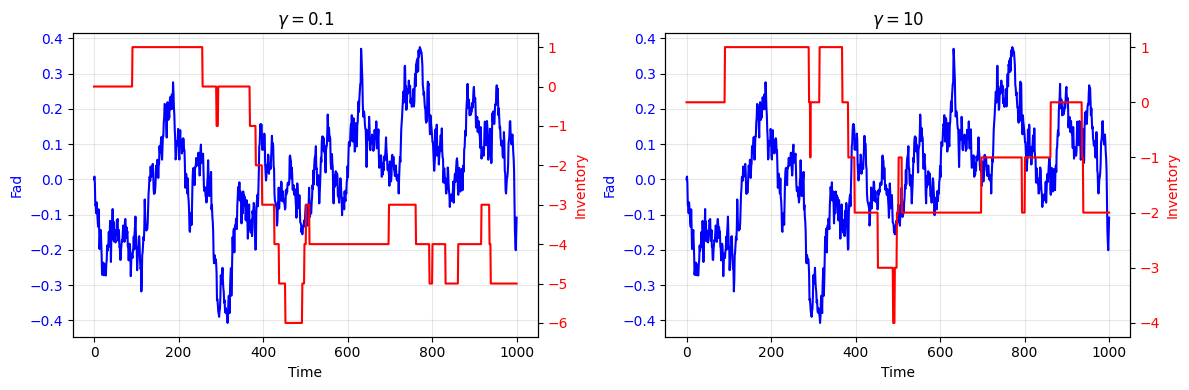

In [46]:
plot_inventory_fad_from_results(results_dict, gamma_values)